# Building a Multimodal RAG Pipeline with Unstructured.io

## 1. System Dependencies

To get started with [Unstructured.io](https://unstructured.io/), we need a few system-wide dependencies:

### 1.1 Poppler ([poppler-utils](https://pypi.org/project/poppler-utils/))

Handles PDF processing. It's a library that can extract text, images, and metadata from PDFs. Unstructured.io uses it to parse PDF documents and convert them into processable text.

### 1.2 Tesseract ([tesseract-ocr](https://github.com/tesseract-ocr/tesseract))

Optical Character Recignition (OCR) engine. When you have scanned documents, images with text, or PDFs that are essentially pictures, Tesseract reads the text from these images and converts it to machine-readable text.

### 1.3 [libmagic](https://pypi.org/project/python-magic/)

File type detection library. It identifies what type of file you're dealing with (PDF, Word Doc, Image, etc.) by analyzing the file's content, not just the extension. This helps Unstructured.io choose the right processing methods for each document.

```python
# for Windows, download using Chocolatey and pip
choco install poppler -y
choco install tesseract -y
pip install python-magic-bin
```

In [1]:
import json
from typing import List

# Unstructured for document parsing
from unstructured.partition.pdf import partition_pdf
from unstructured.chunking.title import chunk_by_title

# LangChain components
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_huggingface import ChatHuggingFace, HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_chroma import Chroma
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv()

C:\Users\GIGA\OneDrive - Universiti Malaya\Documents\rag-for-beginners\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## 2. Partitioning PDF with unstructured

In [2]:
def partition_document(file_path: str):
    """Extract elements from PDF using unstructured"""
    print(f"📄 Partitioning document: {file_path}") 

    elements = partition_pdf(
        filename=file_path, # Path to your PDF file
        strategy="hi_res", # Use the most accurate (but slower) processing method of extraction
        infer_table_structure=True, # Keep tables as structured HTML, not jumbled text
        extract_image_block_types=["Image"], # Grab images found in the PDF
        extract_image_block_to_payload=True # Store images as base64 data you can actually use
    )

    print(f"✅ Extracted {len(elements)} elements")
    return elements

# Test with your PDF file
file_path = "./pdfs/attention-is-all-you-need.pdf"  # Change this to your PDF path
elements = partition_document(file_path)   

📄 Partitioning document: ./pdfs/attention-is-all-you-need.pdf


Loading weights: 100%|█████████████████████████████████████████████████████████████| 367/367 [00:00<00:00, 9985.27it/s]


✅ Extracted 232 elements


In [3]:
elements
# len(elements)

In [4]:
# All types of different atomic elements we see from unstructured
set([str(type(el)) for el in elements])

{"<class 'unstructured.documents.elements.FigureCaption'>",
 "<class 'unstructured.documents.elements.Footer'>",
 "<class 'unstructured.documents.elements.Formula'>",
 "<class 'unstructured.documents.elements.Header'>",
 "<class 'unstructured.documents.elements.Image'>",
 "<class 'unstructured.documents.elements.ListItem'>",
 "<class 'unstructured.documents.elements.NarrativeText'>",
 "<class 'unstructured.documents.elements.Table'>",
 "<class 'unstructured.documents.elements.Text'>",
 "<class 'unstructured.documents.elements.Title'>"}

### 2.1 Viewing sample elements extracted

### 2.2 NarrativeText

In [5]:
# Take an example of 'NarrativeText'
elements[36].to_dict()

{'type': 'NarrativeText',
 'element_id': '620fff7755d3918238f707ae2e1423a7',
 'text': '31st Conference on Neural Information Processing Systems (NIPS 2017), Long Beach, CA, USA.',
 'metadata': {'detection_class_prob': 0.8697527647018433,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(525.0),
     np.float64(3562.4523588888887)),
    (np.float64(525.0), np.float64(3606.0390255555553)),
    (np.float64(2236.7791600000005), np.float64(3606.0390255555553)),
    (np.float64(2236.7791600000005), np.float64(3562.4523588888887))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2026-03-13T13:43:00',
  'filetype': 'application/pdf',
  'languages': ['eng'],
  'page_number': 1,
  'file_directory': './pdfs',
  'filename': 'attention-is-all-you-need.pdf',
  'parent_id': '60b6127e43733a5473c631ca42834955'}}

### 2.3 Images

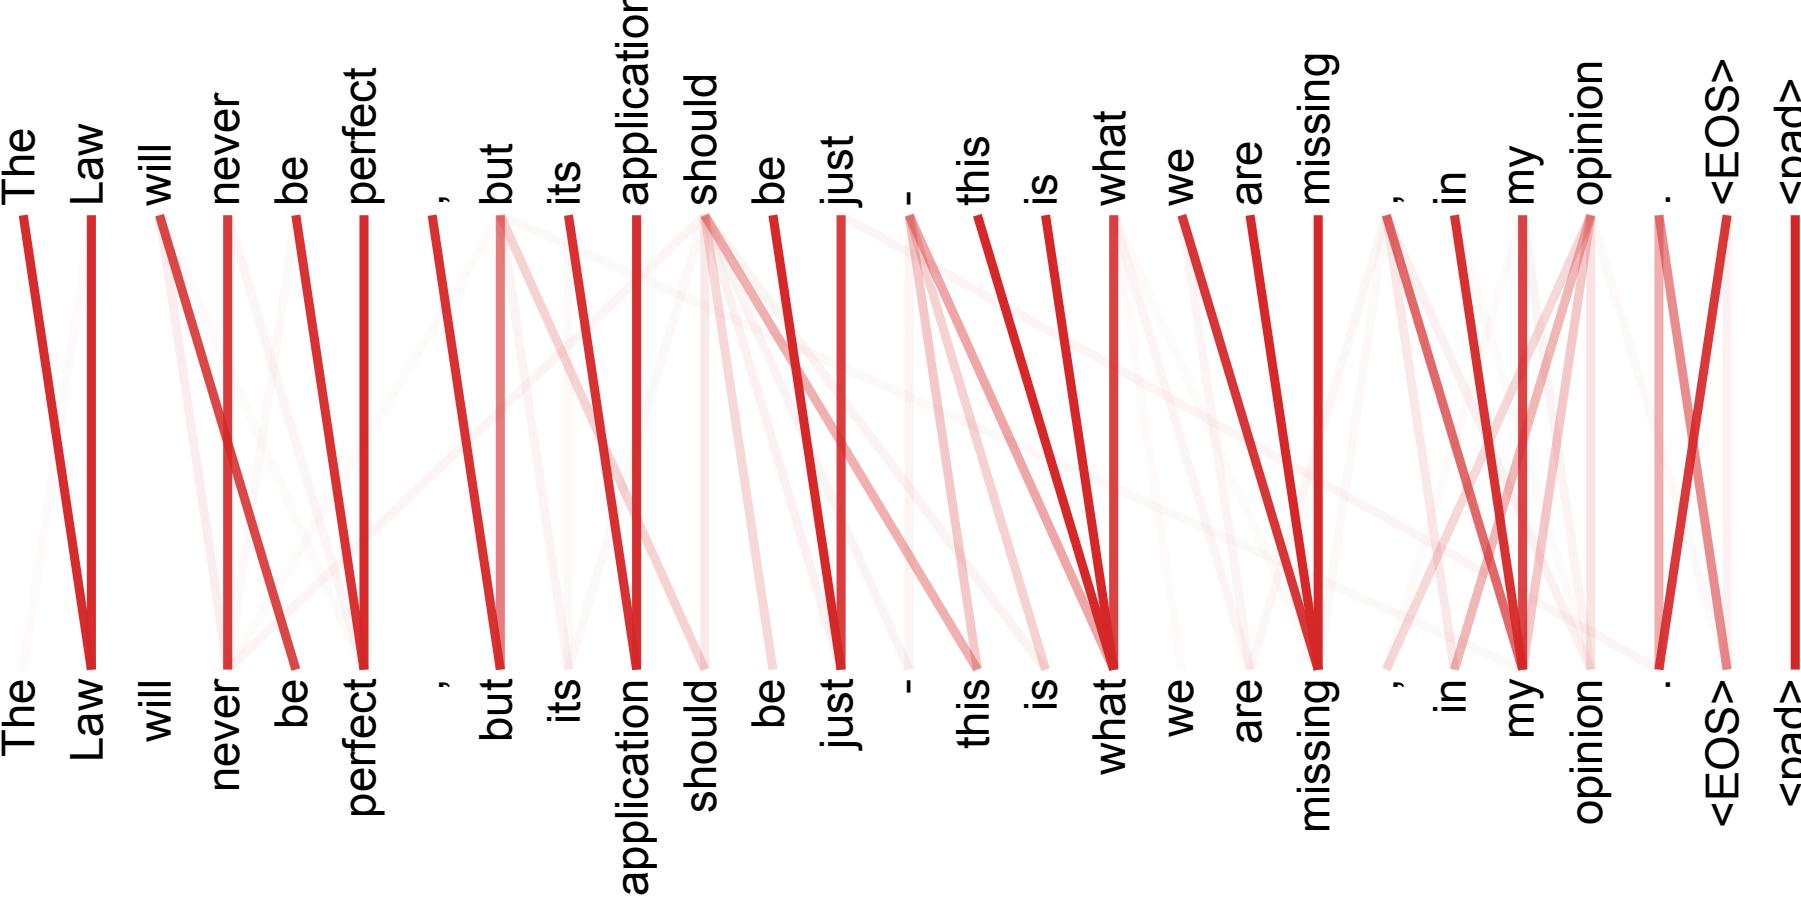

In [6]:
# Print out the base64 image
from PIL import Image
from io import BytesIO
import base64
from IPython.display import display, HTML

# Get the base64 string
image_base64 = elements[-3].metadata.image_base64

# Convert base64 to bytes
image_bytes = base64.b64decode(image_base64)

# Open image with PIL
image = Image.open(BytesIO(image_bytes))

# Display in Jupyter Lab
display(image)

Found 7 images


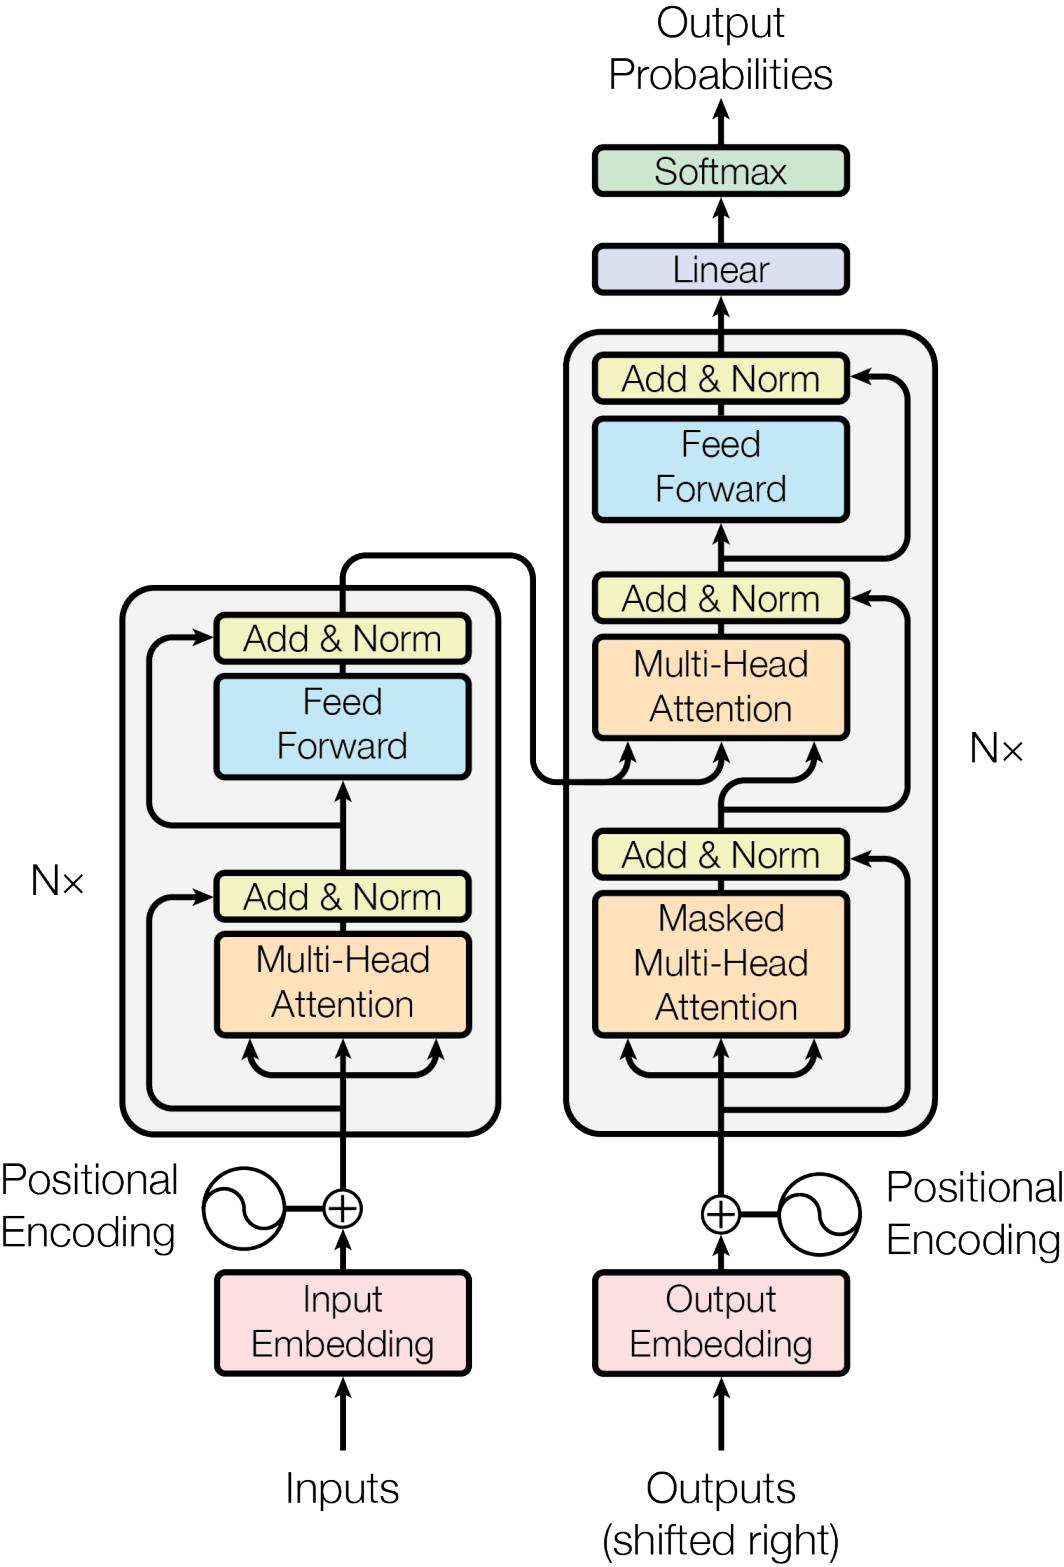

In [7]:
# Gather all images
images = [element for element in elements if element.category == 'Image']
print(f"Found {len(images)} images")

# View first image
# images[0].to_dict()
image_base64 = images[0].metadata.image_base64

# Convert base64 to bytes
image_bytes = base64.b64decode(image_base64)

# Open image with PIL
image = Image.open(BytesIO(image_bytes))

# Display in Jupyter Lab
display(image)

### 2.4 Tables

In [8]:
# Gather all tables
tables = [element for element in elements if element.category == 'Table']
print(f"Found {len(tables)} tables")

# View First table
# tables[0].to_dict()
html_table = tables[0].metadata.text_as_html
display(HTML(html_table))

Found 4 tables


Layer Type,Complexity per Layer,Sequential Operations,Maximum Path Length
Self-Attention,O(n? - d),O(1),O(1)
Recurrent,O(n - d?),O(n),O(n)
Convolutional,O(k-n-d?),O(1),"O(log, (n))"
Self-Attention (restricted),O(r-n-d),O(1),O(n/r)


## 3. Chunking by title

In [9]:
def create_chunks_by_title(elements):
    """Create intelligent chunks using unstructed title-based strategy"""
    print("🔨 Creating smart chunks...")

    chunks = chunk_by_title(
        elements, # The parsed PDF elements from previous step
        max_characters=3000, # Hard limit - never exceed 3000 characters per chunk 
        new_after_n_chars=2400, # Try to start a new chunk after 2400 characters 
        combine_text_under_n_chars=500 # Merge tiny chunks under 500 chars with neighbors
    )

    print(f"✅ Created {len(chunks)} chunks")
    return chunks

# Create chunks
chunks = create_chunks_by_title(elements)

🔨 Creating smart chunks...
✅ Created 25 chunks


In [10]:
# View all chunks
chunks

In [11]:
# All unique types
set([str(type(chunk)) for chunk in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [12]:
# View a single chunk
chunks[2].to_dict()

{'type': 'CompositeElement',
 'element_id': 'a1e46624-f441-45a5-8ef2-c109f6be00f3',
 'text': '1 Introduction\n\nRecurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. Numerous efforts have since continued to push the boundaries of recurrent language models and encoder-decoder architectures [38, 24, 15].\n\nRecurrent models typically factor computation along the symbol positions of the input and output sequences. Aligning the positions to steps in computation time, they generate a sequence of hidden states ht, as a function of the previous hidden state ht−1 and the input for position t. This inherently sequential nature precludes parallelization within training examples, which becomes critical at longer sequence lengths, as memory constraints limit batching across ex

In [13]:
# View all atomic elements built up in chunks/composite element with index 11
chunks[11].metadata.orig_elements

In [14]:
# View original elements (single atomic element in a composite element)
chunks[11].metadata.orig_elements[-1].to_dict()
# chunks[4].metadata.orig_elements[-3].to_dict()
# Note: 4th chunk has the first image + 11th chunk has the first table in the sample PDF

{'type': 'Table',
 'element_id': 'a89281d85d3d589d6b9b2c889815cbce',
 'text': 'Layer Type Complexity per Layer Sequential Maximum Path Length Operations Self-Attention O(n2 · d) O(1) O(1) Recurrent O(n · d2) O(n) O(n) Convolutional O(k · n · d2) O(1) O(logk(n)) Self-Attention (restricted) O(r · n · d) O(1) O(n/r)',
 'metadata': {'detection_class_prob': 0.9282334446907043,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(561.3707885742188),
     np.float64(550.45751953125)),
    (np.float64(561.3707885742188), np.float64(908.8243408203125)),
    (np.float64(2395.140380859375), np.float64(908.8243408203125)),
    (np.float64(2395.140380859375), np.float64(550.45751953125))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2026-03-13T13:43:00',
  'text_as_html': '<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Att

## 4. AI Enhanced Chunks Summary

In [16]:
def separate_content_types(chunk):
    """Analyze what types of content are in a chunk"""
    content_data = {
        'text': chunk.text,
        'tables': [],
        'images': [],
        'types': ['text']
    }
    
    # Check for tables and images in original elements
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for element in chunk.metadata.orig_elements:
            element_type = type(element).__name__
            
            # Handle tables
            if element_type == 'Table':
                content_data['types'].append('table')
                table_html = getattr(element.metadata, 'text_as_html', element.text)
                content_data['tables'].append(table_html)
            
            # Handle images
            elif element_type == 'Image':
                if hasattr(element, 'metadata') and hasattr(element.metadata, 'image_base64'):
                    content_data['types'].append('image')
                    content_data['images'].append(element.metadata.image_base64)
    
    content_data['types'] = list(set(content_data['types']))
    return content_data

def create_ai_enhanced_summary(text: str, tables: List[str], images: List[str]) -> str:
    """Create AI-enhanced summary for mixed content"""
    
    try:
        # Initialize LLM (needs vision model for images)
        llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
        
        # Build the text prompt
        prompt_text = f"""You are creating a searchable description for document content retrieval.

        CONTENT TO ANALYZE:
        TEXT CONTENT:
        {text}

        """
        
        # Add tables if present
        if tables:
            prompt_text += "TABLES:\n"
            for i, table in enumerate(tables):
                prompt_text += f"Table {i+1}:\n{table}\n\n"
        
                prompt_text += """
                YOUR TASK:
                Generate a comprehensive, searchable description that covers:

                1. Key facts, numbers, and data points from text and tables
                2. Main topics and concepts discussed  
                3. Questions this content could answer
                4. Visual content analysis (charts, diagrams, patterns in images)
                5. Alternative search terms users might use

                Make it detailed and searchable - prioritize findability over brevity.

                SEARCHABLE DESCRIPTION:"""

        # Build message content starting with text
        message_content = [{"type": "text", "text": prompt_text}]
        
        # Add images to the message
        for image_base64 in images:
            message_content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
            })
        
        # Send to AI and get response
        message = HumanMessage(content=message_content)
        response = llm.invoke([message])
        
        return response.content
        
    except Exception as e:
        print(f"     ❌ AI summary failed: {e}")
        # Fallback to simple summary
        summary = f"{text[:300]}..."
        if tables:
            summary += f" [Contains {len(tables)} table(s)]"
        if images:
            summary += f" [Contains {len(images)} image(s)]"
        return summary
        
def summarise_chunks(chunks):
    """Process all chunks with AI Summaries"""
    print("🧠 Processing chunks with AI Summaries...")
    
    langchain_documents = []
    total_chunks = len(chunks)
    
    for i, chunk in enumerate(chunks):
        current_chunk = i + 1
        print(f"   Processing chunk {current_chunk}/{total_chunks}")
        
        # Analyze chunk content
        content_data = separate_content_types(chunk)
        
        # Debug prints
        print(f"     Types found: {content_data['types']}")
        print(f"     Tables: {len(content_data['tables'])}, Images: {len(content_data['images'])}")
        
        # Create AI-enhanced summary if chunk has tables/images
        if content_data['tables'] or content_data['images']:
            print(f"     → Creating AI summary for mixed content...")
            try:
                enhanced_content = create_ai_enhanced_summary(
                    content_data['text'],
                    content_data['tables'], 
                    content_data['images']
                )
                print(f"     → AI summary created successfully")
                print(f"     → Enhanced content preview: {enhanced_content[:200]}...")
            except Exception as e:
                print(f"     ❌ AI summary failed: {e}")
                enhanced_content = content_data['text']
        else:
            print(f"     → Using raw text (no tables/images)")
            enhanced_content = content_data['text']
        
        # Create LangChain Document with rich metadata
        doc = Document(
            page_content=enhanced_content,
            metadata={
                "original_content": json.dumps({
                    "raw_text": content_data['text'],
                    "tables_html": content_data['tables'],
                    "images_base64": content_data['images']
                })
            }
        )
        
        langchain_documents.append(doc)
    
    print(f"✅ Processed {len(langchain_documents)} chunks")
    return langchain_documents


# Process chunks with AI
processed_chunks = summarise_chunks(chunks)

🧠 Processing chunks with AI Summaries...
   Processing chunk 1/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 2/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 3/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 4/25
     Types found: ['text']
     Tables: 0, Images: 0
     → Using raw text (no tables/images)
   Processing chunk 5/25
     Types found: ['image', 'text']
     Tables: 0, Images: 1
     → Creating AI summary for mixed content...
     → AI summary created successfully
     → Enhanced content preview: ### Searchable Description for Document Content Retrieval

**Title:** Model Architecture Overview

**Keywords:** Neural Sequence Transduction, Encoder-Decoder, Transformer, Self-Attention, Multi-Head ...
   Processing chunk 6/25
     Types found: ['text']
     Tables: 0, Imag

In [18]:
processed_chunks

[Document(metadata={'original_content': '{"raw_text": "3\\n\\n2023\\n\\n2\\n\\n0\\n\\n2\\n\\ng u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0 7\\n\\n1\\n\\n:\\n\\nv\\n\\narXiv\\n\\ni\\n\\nX\\n\\nr\\n\\na\\n\\nProvided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\\n\\nAttention Is All You Need\\n\\nAshish Vaswani\\u2217\\n\\nGoogle Brain\\n\\navaswani@google.com\\n\\nNoam Shazeer\\u2217\\n\\nGoogle Brain noam@google.com\\n\\nNiki Parmar\\u2217\\n\\nGoogle Research nikip@google.com\\n\\nJakob Uszkoreit\\u2217\\n\\nGoogle Research usz@google.com\\n\\nLlion Jones\\u2217\\n\\nGoogle Research llion@google.com\\n\\nAidan N. Gomez\\u2217 \\u2020 University of Toronto aidan@cs.toronto.edu\\n\\n\\u0141ukasz Kaiser\\u2217 Google Brain lukaszkaiser@google.com", "tables_html": [], "images_base64": []}'}, page_content='3\n\n2023\n\n2\n\n0\n\n2\n\ng u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0 

## 5. Export Chunks to JSON

In [19]:
def export_chunks_to_json(chunks, filename="chunks_export.json"):
    """Export processed chunks to clean JSON format"""
    export_data = []
    
    for i, doc in enumerate(chunks):
        chunk_data = {
            "chunk_id": i + 1,
            "enhanced_content": doc.page_content,
            "metadata": {
                "original_content": json.loads(doc.metadata.get("original_content", "{}"))
            }
        }
        export_data.append(chunk_data)
    
    # Save to file
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Exported {len(export_data)} chunks to {filename}")
    return export_data

# Export your chunks
json_data = export_chunks_to_json(processed_chunks)

✅ Exported 25 chunks to chunks_export.json


## 6. Vector Store

In [20]:
def create_vector_store(documents, persist_directory="dbv1/chroma_db"):
    """Create and persist ChromaDB vector store"""
    print("🔮 Creating embeddings and storing in ChromaDB...")
        
    embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
    
    # Create ChromaDB vector store
    print("--- Creating vector store ---")
    vectorstore = Chroma.from_documents(
        documents=documents,
        embedding=embedding_model,
        persist_directory=persist_directory, 
        collection_metadata={"hnsw:space": "cosine"}
    )
    print("--- Finished creating vector store ---")
    
    print(f"✅ Vector store created and saved to {persist_directory}")
    return vectorstore

# Create the vector store
db = create_vector_store(processed_chunks)

🔮 Creating embeddings and storing in ChromaDB...
--- Creating vector store ---
--- Finished creating vector store ---
✅ Vector store created and saved to dbv1/chroma_db


## 7. Retrieval

In [21]:
# After your retrieval
query = "What are the two main components of the Transformer architecture? "
retriever = db.as_retriever(search_kwargs={"k": 3})
chunks = retriever.invoke(query)

# Export to JSON
export_chunks_to_json(chunks, "rag_results.json")

✅ Exported 3 chunks to rag_results.json


[{'chunk_id': 1,
  'enhanced_content': '### Searchable Description for Document Content Retrieval\n\n**Title:** Model Architecture Overview\n\n**Keywords:** Neural Sequence Transduction, Encoder-Decoder, Transformer, Self-Attention, Multi-Head Attention, Auto-Regressive Model, Positional Encoding\n\n**Summary:**\nThis document section discusses the architecture of competitive neural sequence transduction models, specifically focusing on the encoder-decoder structure. The encoder transforms an input sequence into continuous representations, while the decoder generates an output sequence in an auto-regressive manner. The Transformer model is highlighted, utilizing stacked self-attention and fully connected layers for both the encoder and decoder. Key components include multi-head attention, feed-forward layers, and positional encoding, as illustrated in the accompanying figure.\n\n**Key Concepts:**\n- **Encoder-Decoder Structure:** Maps input sequences to continuous representations and g

## 8. Complete Ingestion Pipeline

In [ ]:
def run_complete_ingestion_pipeline(pdf_path: str):
    """Run the complete RAG ingestion pipeline"""
    print("🚀 Starting RAG Ingestion Pipeline")
    print("=" * 50)
    
    # Step 1: Partition
    elements = partition_document(pdf_path)
    
    # Step 2: Chunk
    chunks = create_chunks_by_title(elements)
    
    # Step 3: AI Summarisation
    summarised_chunks = summarise_chunks(chunks)
    
    # Step 4: Vector Store
    db = create_vector_store(summarised_chunks, persist_directory="dbv2/chroma_db")
    
    print("🎉 Pipeline completed successfully!")
    return db

# Run the complete pipeline

db = run_complete_ingestion_pipeline("./pdfs/attention-is-all-you-need.pdf")

## 9. Generation

In [23]:
# Query the vector store
query = "According to Table 1, what are the main advantages of self-attention layers compared to recurrent and convolutional layers in terms of computational complexity and parallelization?"

retriever = db.as_retriever(search_kwargs={"k": 3})
chunks = retriever.invoke(query)

def generate_final_answer(chunks, query):
    """Generate final answer using multimodal content"""
    
    try:
        # Initialize LLM (needs vision model for images)
        llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
        
        # Build the text prompt
        prompt_text = f"""Based on the following documents, please answer this question: {query}

CONTENT TO ANALYZE:
"""
        
        for i, chunk in enumerate(chunks):
            prompt_text += f"--- Document {i+1} ---\n"
            
            if "original_content" in chunk.metadata:
                original_data = json.loads(chunk.metadata["original_content"])
                
                # Add raw text
                raw_text = original_data.get("raw_text", "")
                if raw_text:
                    prompt_text += f"TEXT:\n{raw_text}\n\n"
                
                # Add tables as HTML
                tables_html = original_data.get("tables_html", [])
                if tables_html:
                    prompt_text += "TABLES:\n"
                    for j, table in enumerate(tables_html):
                        prompt_text += f"Table {j+1}:\n{table}\n\n"
            
            prompt_text += "\n"
        
        prompt_text += """
Please provide a clear, comprehensive answer using the text, tables, and images above. If the documents don't contain sufficient information to answer the question, say "I don't have enough information to answer that question based on the provided documents."

ANSWER:"""

        # Build message content starting with text
        message_content = [{"type": "text", "text": prompt_text}]
        
        # Add all images from all chunks
        for chunk in chunks:
            if "original_content" in chunk.metadata:
                original_data = json.loads(chunk.metadata["original_content"])
                images_base64 = original_data.get("images_base64", [])
                
                for image_base64 in images_base64:
                    message_content.append({
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                    })
        
        # Send to AI and get response
        message = HumanMessage(content=message_content)
        response = llm.invoke([message])
        
        return response.content
        
    except Exception as e:
        print(f"❌ Answer generation failed: {e}")
        return "Sorry, I encountered an error while generating the answer."

# Usage
final_answer = generate_final_answer(chunks, query)
print(final_answer)

According to Table 1, the main advantages of self-attention layers compared to recurrent and convolutional layers in terms of computational complexity and parallelization are as follows:

1. **Computational Complexity**: Self-attention layers have a constant number of sequentially executed operations, which makes them faster than recurrent layers when the sequence length \( n \) is smaller than the representation dimensionality \( d \). In contrast, recurrent layers require \( O(n) \) sequential operations, which can become a bottleneck for longer sequences. Convolutional layers, while generally more expensive than recurrent layers, also do not connect all pairs of input and output positions directly, requiring multiple layers to achieve similar connectivity.

2. **Parallelization**: Self-attention allows for significant parallelization since it does not rely on sequential computation like recurrent layers do. Recurrent layers inherently process input in a sequential manner, which limi